# **XGBoost for PJME Electricity Consumption Data**

### **Learning Resources**
[Getting started with XGBoost](https://www.youtube.com/watch?v=vV12dGe_Fho) by Rob Mulla  
[Advanced Time-series Techniques](https://www.youtube.com/watch?v=z3ZnOW-S550&t=1s) by Rob Mulla  
[TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) from sklearn docs

### **Learning Points**
* If plot shows weird lines, it is likely because the df index is not sorted. `df = df.sort_index()`
* Calculate and sort descending `error` as a way to quickly see where your model performs poorly or to identify anomalous data points `error = actual - pred`
* Time-series split (Cross-validation) tests whether the model generalises forward in time, which is the actual real-world task. Normal cross-validation is invalid, the model would train on future data to predict the past, breaking temporal dependencies (past values influence today's value)

---

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb

# global plot style
plt.style.use('fivethirtyeight')
sns.set_theme(
  style='darkgrid',
  palette='muted',
  rc={
    'figure.figsize': (15, 5),
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
  }
)

---

### Load & Preview Dataset

In [52]:
df = pd.read_csv("data/PJME_hourly.csv")
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()
print(f"No. rows: {df.shape[0]}")
df.head()

No. rows: 145366


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## EDA

In [53]:
df.describe(include='all')

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


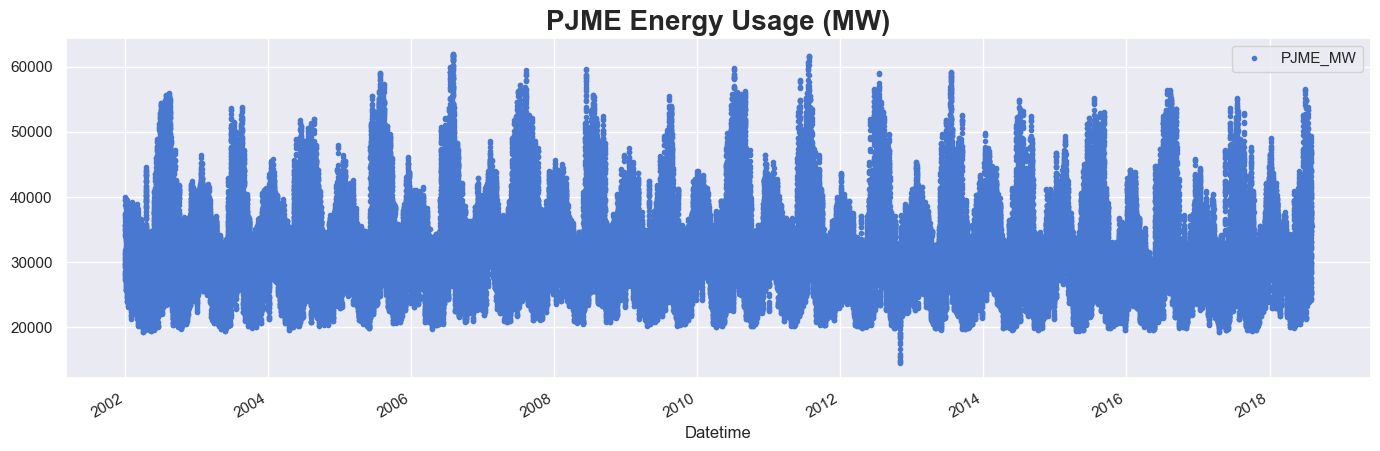

In [54]:
df.plot(
  style='.', 
  title="PJME Energy Usage (MW)"
)
plt.show()

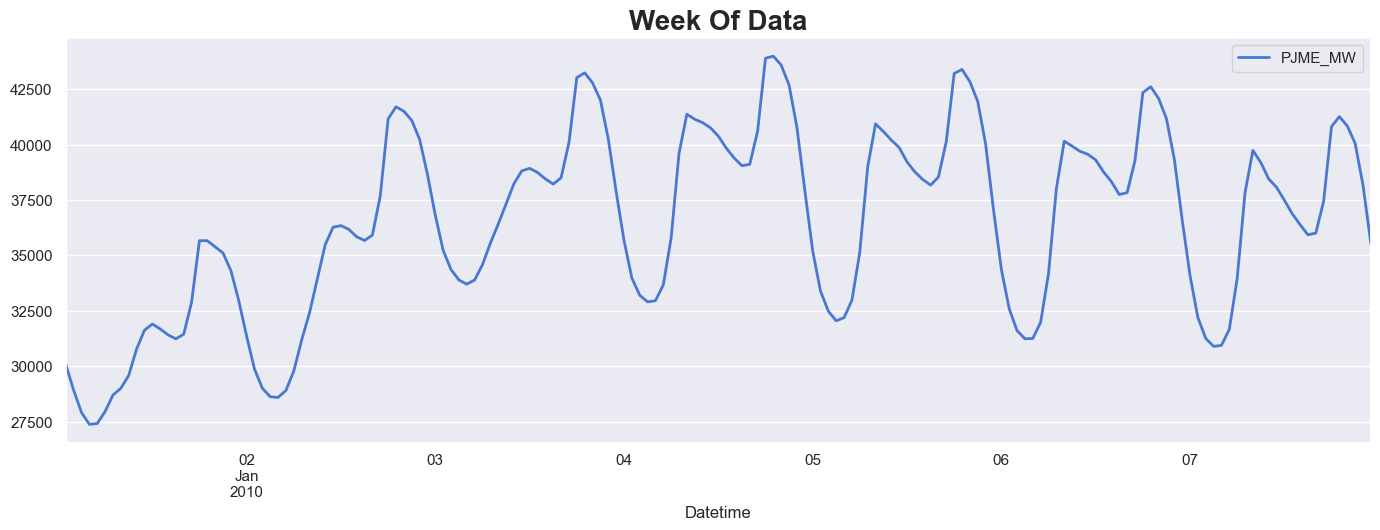

In [55]:
df.loc[(df.index > '2010-01-01') & (df.index < '2010-01-08')] \
  .plot(figsize=(15, 5), title='Week Of Data', linewidth=2)
plt.show()

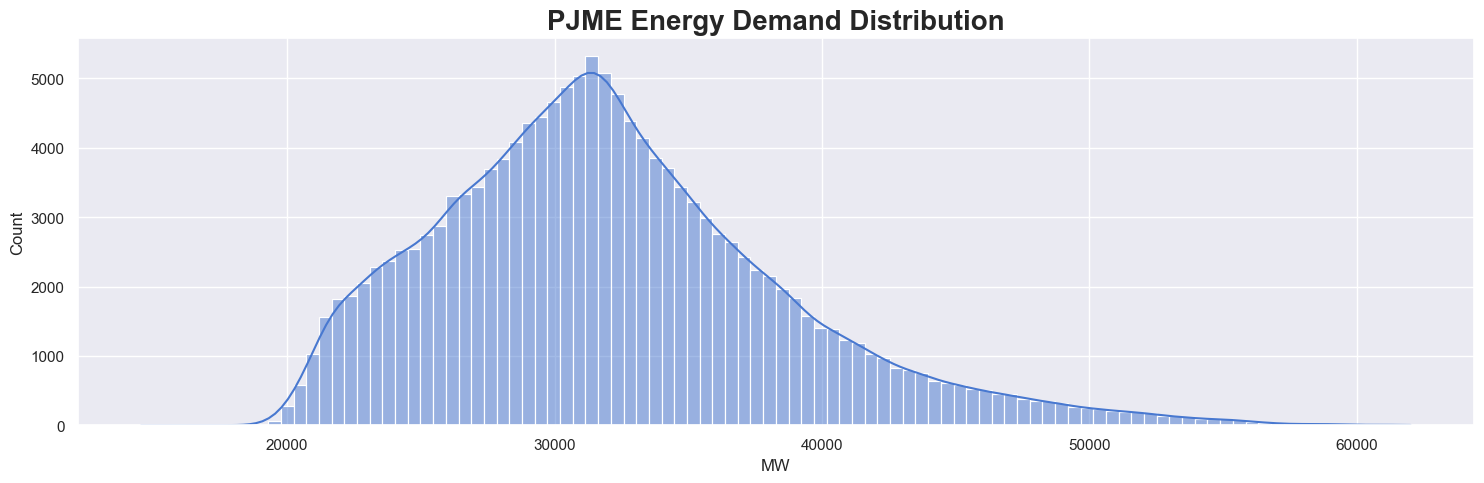

In [56]:
sns.histplot(
  data=df,
  x='PJME_MW',
  bins=100,
  kde=True
)
plt.title('PJME Energy Demand Distribution')
plt.xlabel('MW')
plt.tight_layout()
plt.show()

### Investigate Anomalous Trough around 2013

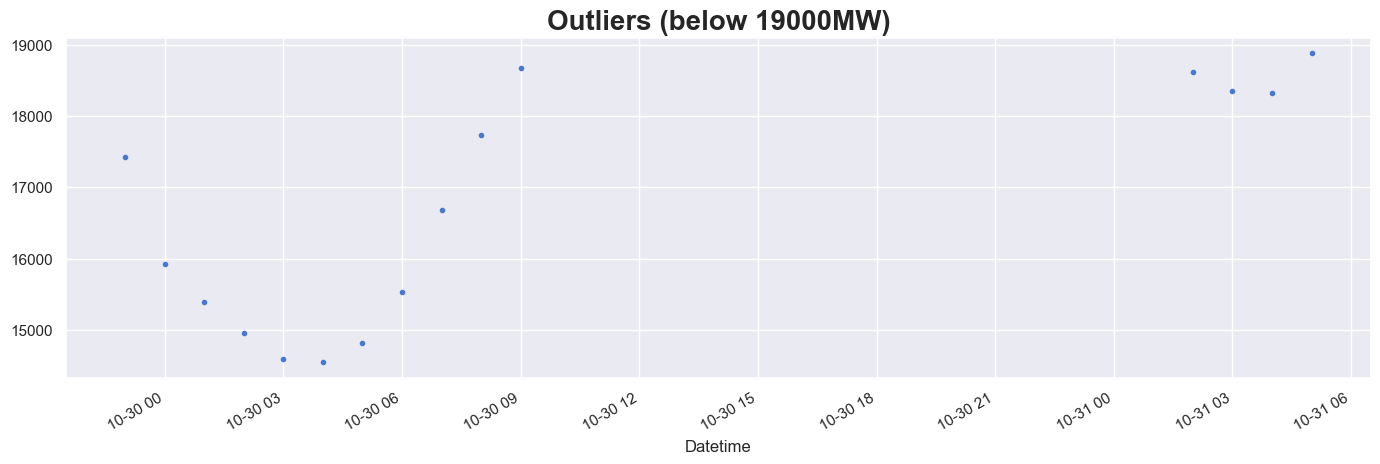

In [57]:
df.loc[(df["PJME_MW"] < 19000), "PJME_MW"].plot(
  style=".",
  title="Outliers (below 19000MW)"
)
plt.show()

In [58]:
# Remove outlier data
df = df.query("PJME_MW > 19000")
df.describe().loc[["min", "max"], "PJME_MW"]

min    19085.0
max    62009.0
Name: PJME_MW, dtype: float64

## Feature Engineering for XGBoost

In [59]:
def create_features(df):
  df = df.copy()
  df['hour']       = df.index.hour
  df['dayofweek']  = df.index.dayofweek
  df['month']      = df.index.month
  df['quarter']    = df.index.quarter
  df['year']       = df.index.year
  df['dayofyear']  = df.index.dayofyear
  df['dayofmonth'] = df.index.day
  df['weekofyear'] = df.index.isocalendar().week.astype(int)
  return df

df = create_features(df)
df.head(1)

,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1


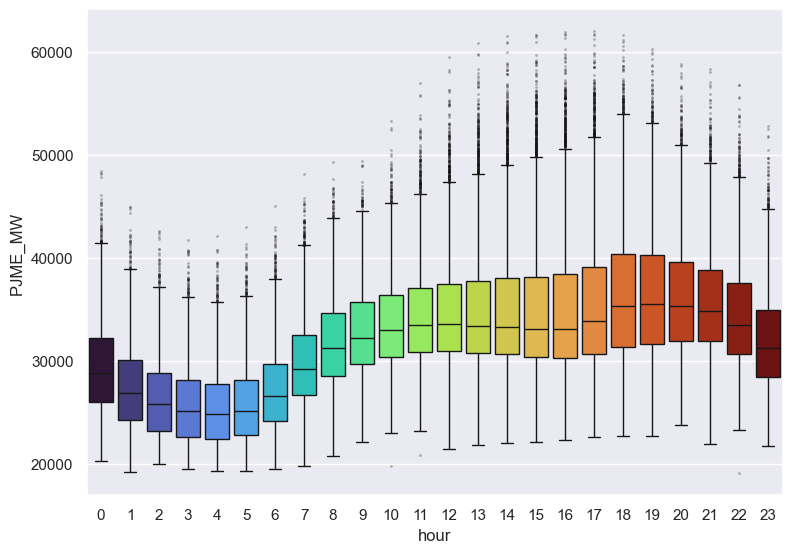

In [60]:
plt.figure(figsize=(8, 6))
sns.boxplot(
  data=df, 
  x='hour', y='PJME_MW',
  palette='turbo', hue="hour", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

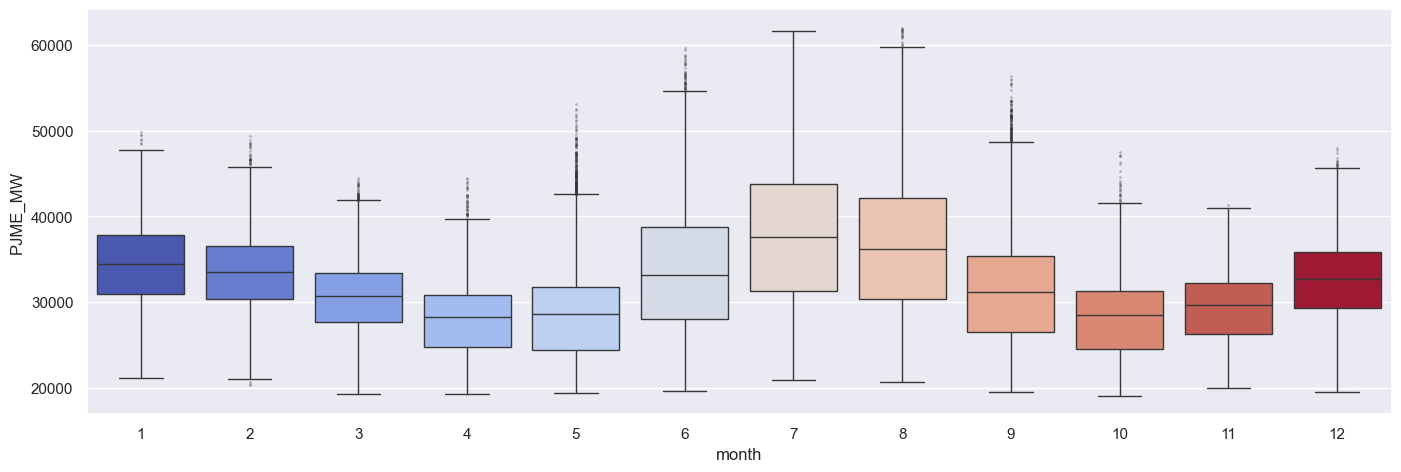

In [61]:
sns.boxplot(
  data=df, 
  x='month', y='PJME_MW',
  palette='coolwarm', hue="month", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

## Model Training

In [62]:
tscv = TimeSeriesSplit(
  test_size=24*7*12, 
  gap=24
) # 12 weeks per fold

TARGET = 'PJME_MW'

Fold 0: Train=108975 rows, Test=2016 rows
Fold 1: Train=110991 rows, Test=2016 rows
Fold 2: Train=113007 rows, Test=2016 rows
Fold 3: Train=115023 rows, Test=2016 rows
Fold 4: Train=117039 rows, Test=2016 rows


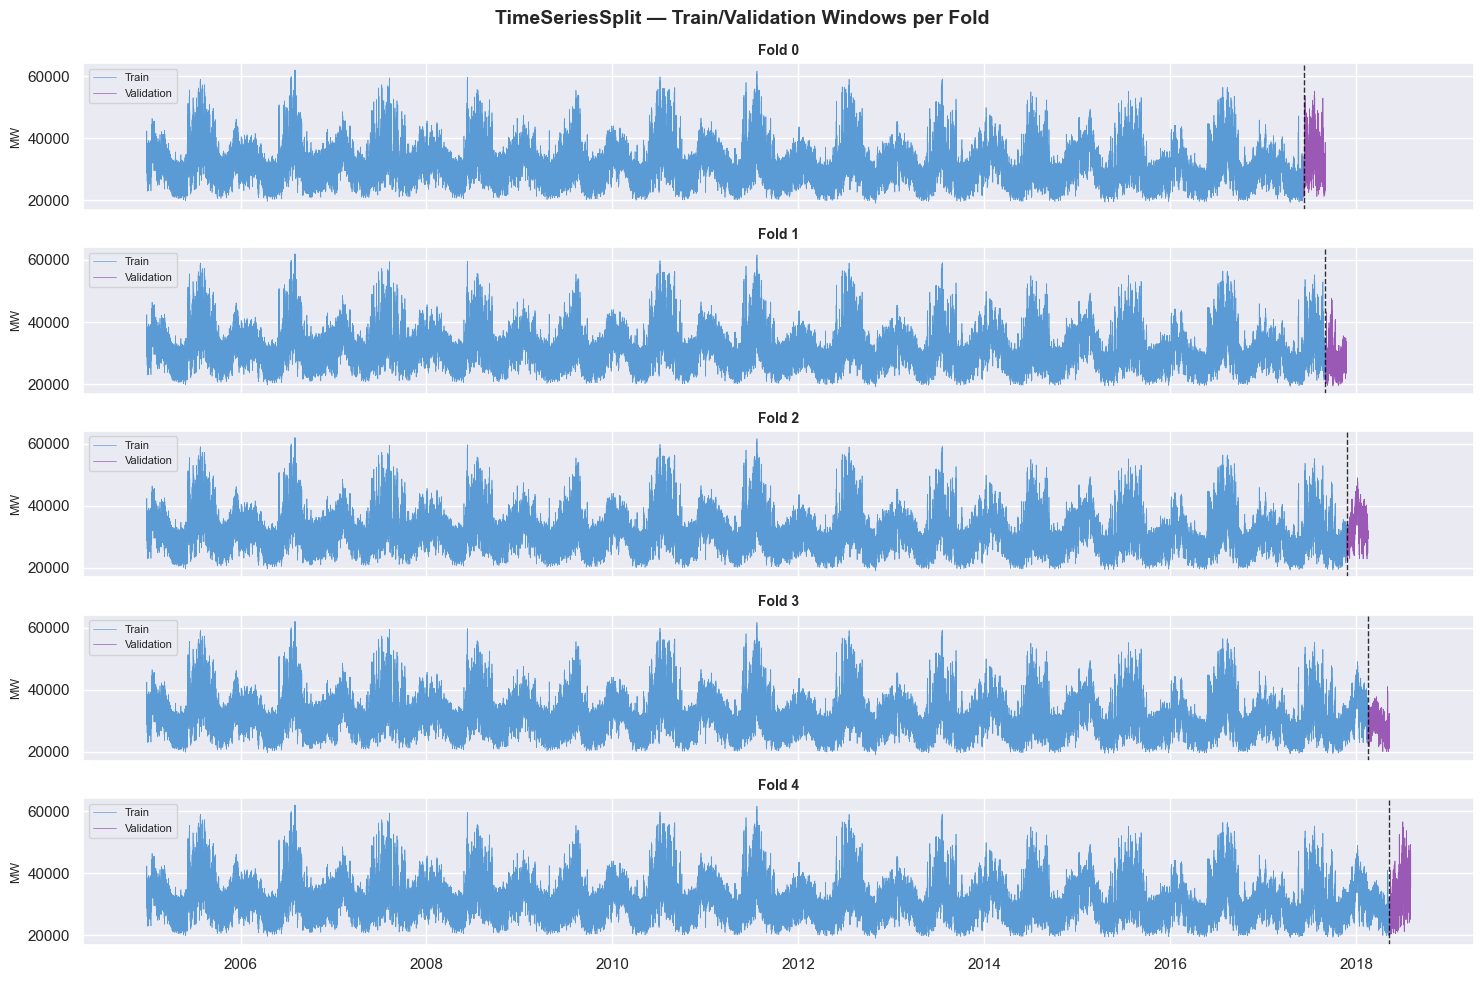

[0]	validation_0-rmse:6484.76642	validation_1-rmse:7743.92845
[100]	validation_0-rmse:4692.82332	validation_1-rmse:5254.08904
[200]	validation_0-rmse:4037.19144	validation_1-rmse:4584.79376
[300]	validation_0-rmse:3658.21623	validation_1-rmse:4501.97182
[400]	validation_0-rmse:3446.04207	validation_1-rmse:4478.19354
[500]	validation_0-rmse:3323.00779	validation_1-rmse:4466.88586
[600]	validation_0-rmse:3248.86726	validation_1-rmse:4436.57799
[700]	validation_0-rmse:3198.01730	validation_1-rmse:4417.71090
[800]	validation_0-rmse:3156.63280	validation_1-rmse:4401.93808
[900]	validation_0-rmse:3125.89598	validation_1-rmse:4396.41992
[950]	validation_0-rmse:3111.20067	validation_1-rmse:4401.33037
Fold 0 RMSE: 4396.4MW
[0]	validation_0-rmse:6509.60832	validation_1-rmse:6126.21135
[100]	validation_0-rmse:4696.12634	validation_1-rmse:5034.60984
[200]	validation_0-rmse:4050.84404	validation_1-rmse:4615.92562
[300]	validation_0-rmse:3687.29563	validation_1-rmse:4355.35805
[400]	validation_0-rms

In [78]:
FEATURES = [
  'hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'dayofmonth', 'weekofyear'
]

# collect data for the 5 regressors across 5 folds for analysis later
fold_scores = []
predictions_raw = pd.DataFrame()
feature_importances = pd.DataFrame(index=FEATURES)

fig, axes = plt.subplots(5, 1, figsize=(15, 10), sharex=True)
fig.suptitle('TimeSeriesSplit — Train/Validation Windows per Fold', fontsize=14, fontweight='bold')

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):
  print(f"Fold {fold}: Train={len(train_idx)} rows, Test={len(test_idx)} rows")

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Plot train/validation split per fold
  ax = axes[fold]
  ax.plot(y_train.index, y_train.values, color='#5B9BD5', linewidth=0.5, label='Train')
  ax.plot(y_test.index,  y_test.values,  color='#9B59B6', linewidth=0.5, label='Validation')
  ax.axvline(y_test.index.min(), color="black", linewidth=1, alpha=0.8, ls="--")
  ax.set_ylabel('MW', fontsize=9)
  ax.set_title(f'Fold {fold}', fontsize=10)
  ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Train XGB
  reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=50, # prevent overfitting by stopping model if validation metric (RMSE) increases above previous rounds
    eval_metric='rmse'
  )
  reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
  )

  # Predict
  preds = reg.predict(X_test)
  score = np.sqrt(np.mean((preds - y_test)**2)) # RMSE in MW
  fold_scores.append(score)
  print(f"Fold {fold} RMSE: {score:.1f}MW")

  # Save data (feat importances, predictions)
  fold_preds = pd.DataFrame({
    'actual':   y_test.values,
    'predicted': preds,
    'fold':      fold
  }, index=y_test.index)
  predictions_raw = pd.concat([predictions_raw, fold_preds])
  feature_importances[f'fold_{fold}'] = reg.feature_importances_

print(f"\nMean RMSE: {np.mean(fold_scores):.1f} ± {np.std(fold_scores):.1f} MW")

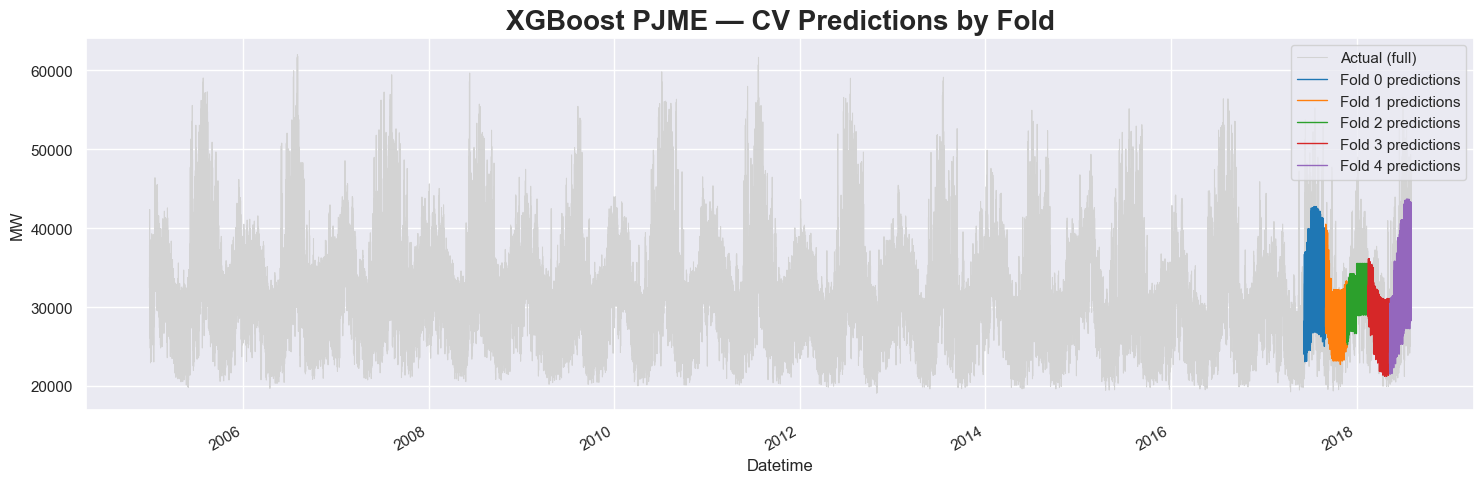

In [79]:
fig, ax = plt.subplots(figsize=(15, 5))

# Full actual series in the background
df[TARGET].plot(ax=ax, color='lightgray', label='Actual (full)', linewidth=0.75)

# Overlay each fold's predictions in a distinct color
colors = plt.cm.tab10.colors
for fold in predictions_raw['fold'].unique():
  mask = predictions_raw['fold'] == fold
  predictions_raw.loc[mask, 'predicted'].plot(
    ax=ax, color=colors[fold], label=f'Fold {fold} predictions', linewidth=1
  )

ax.set_title('XGBoost PJME — CV Predictions by Fold')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
ax.legend()
plt.tight_layout()
plt.show()

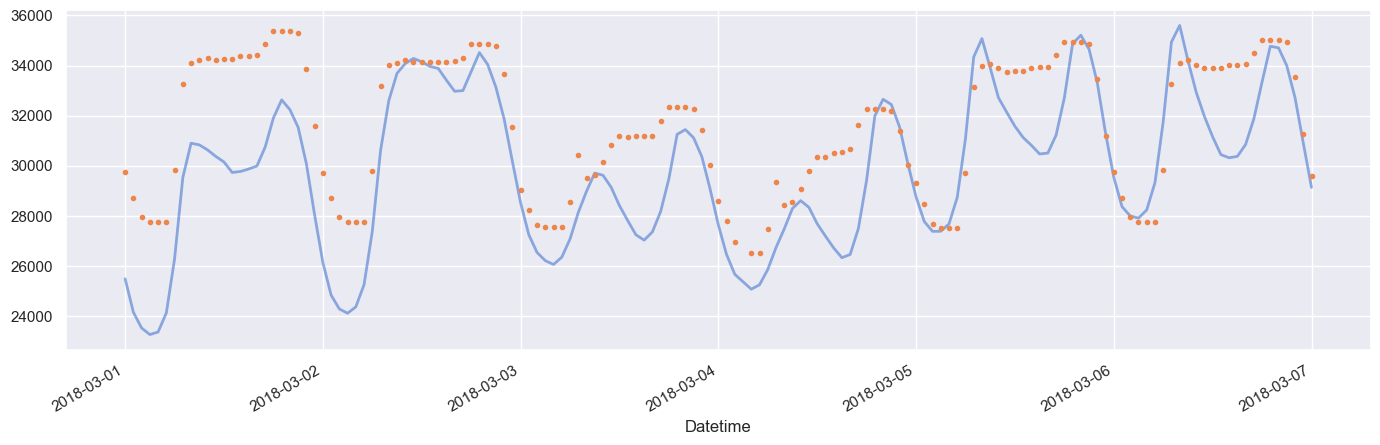

In [80]:
YEAR = 2018
MONTH = 3

mask = (predictions_raw.index >= f'{YEAR}-{MONTH}-01') & (predictions_raw.index <= f'{YEAR}-{MONTH}-07')
predictions_raw.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions_raw.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)
plt.show()

### Feature Importances

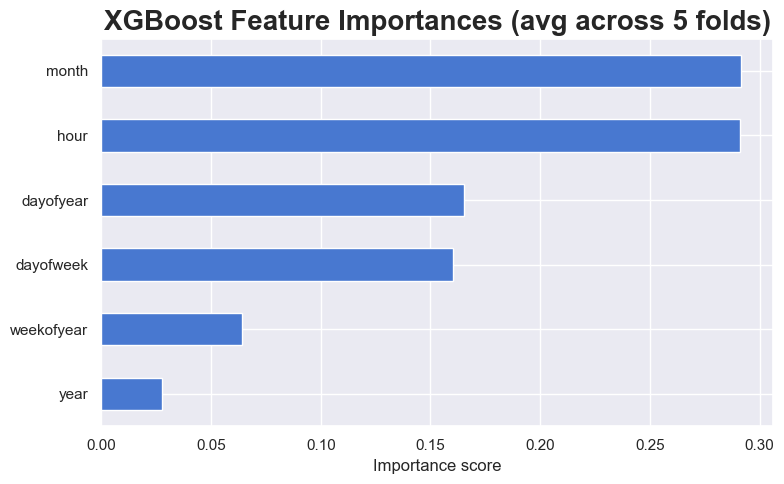

In [66]:
# avg across folds and sort
feature_importances['mean'] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values('mean', ascending=True)

feature_importances['mean'].plot(
  kind='barh',
  figsize=(8, 5),
  title='XGBoost Feature Importances (avg across 5 folds)'
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

Features like month and dayofyear are highly correlated. Removing month may cause the importance of dayofyear to spike. The raw feature importances are not always the most reliable metric to evaluate each individual feature, moreso how they all work together.

### Calculate Error

In [67]:
predictions_raw["error"] = np.abs(predictions_raw["actual"] - predictions_raw["predicted"])
predictions_raw["date"] = predictions_raw.index.date
predictions_raw.groupby("date")["error"].mean().sort_values(ascending=False).head(10)

date
2018-01-06    11455.945801
2018-01-05    10342.170329
2018-01-07    10294.827799
2018-07-02     9664.567057
2018-07-03     9443.961995
2017-12-31     9224.077555
2017-06-13     8427.158366
2018-07-01     8424.606689
2017-09-27     8407.814128
2017-09-25     8218.610677
Name: error, dtype: float64

### Add Lag Features

In [68]:
def add_lags(df):
  df = df.copy()
  target_map = df["PJME_MW"].to_dict()
  df["lag1"] = (df.index - pd.Timedelta('364 days')).map(target_map)
  df["lag2"] = (df.index - pd.Timedelta('728 days')).map(target_map)
  df["lag3"] = (df.index - pd.Timedelta('1092 days')).map(target_map)
  return df

def add_rolling(df):
  df = df.copy()
  df['rolling_mean_24h']  = df['PJME_MW'].shift(1).rolling(24).mean()   # yesterday's avg
  df['rolling_mean_168h'] = df['PJME_MW'].shift(1).rolling(168).mean()  # last week's avg
  return df

df = add_lags(df)
df = add_rolling(df)
df = df.dropna()

print(f"No. rows after cleaning: {df.shape[0]}")
df.head(1)

No. rows after cleaning: 119079


,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,rolling_mean_24h,rolling_mean_168h
Datetime,,,,,,,,,,,,,,
2004-12-28 01:00:00,33781.0,1,1,12,4,2004,363,28,53,26506.0,26498.0,30393.0,36852.708333,34119.214286


In [81]:
FEATURES = [
  'hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 
  'lag1', 'lag2', 'lag3',
]

# collect data for the 5 regressors across 5 folds for analysis later
fold_scores = []
predictions_lag = pd.DataFrame()
feature_importances = pd.DataFrame(index=FEATURES)

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Train XGB
  reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric='rmse'
  )
  reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
  )

  # Predict
  preds = reg.predict(X_test)
  score = np.sqrt(np.mean((preds - y_test)**2)) # RMSE in MW
  fold_scores.append(score)
  print(f"Fold {fold} RMSE: {score:.1f}MW")

  # Save data (feat importances, predictions)
  fold_preds = pd.DataFrame({
    'actual':   y_test.values,
    'predicted': preds,
    'fold':      fold
  }, index=y_test.index)
  predictions_lag = pd.concat([predictions_lag, fold_preds])
  feature_importances[f'fold_{fold}'] = reg.feature_importances_

print(f"\nMean RMSE: {np.mean(fold_scores):.1f} ± {np.std(fold_scores):.1f} MW")

[0]	validation_0-rmse:6470.84937	validation_1-rmse:7727.54989
[100]	validation_0-rmse:4227.63149	validation_1-rmse:5141.82786
[200]	validation_0-rmse:3661.91706	validation_1-rmse:4768.43990
[300]	validation_0-rmse:3473.04797	validation_1-rmse:4679.69244
[383]	validation_0-rmse:3397.53142	validation_1-rmse:4723.86559
Fold 0 RMSE: 4663.9MW
[0]	validation_0-rmse:6495.85389	validation_1-rmse:6107.84674
[100]	validation_0-rmse:4252.09278	validation_1-rmse:4079.45843
[200]	validation_0-rmse:3690.70219	validation_1-rmse:3787.65669
[292]	validation_0-rmse:3512.96491	validation_1-rmse:3818.10512
Fold 1 RMSE: 3768.9MW
[0]	validation_0-rmse:6489.11589	validation_1-rmse:5272.35650
[100]	validation_0-rmse:4253.65478	validation_1-rmse:4248.87370
[200]	validation_0-rmse:3695.11235	validation_1-rmse:4148.10342
[221]	validation_0-rmse:3644.73217	validation_1-rmse:4166.42322
Fold 2 RMSE: 4134.8MW
[0]	validation_0-rmse:6469.83245	validation_1-rmse:4958.86993
[100]	validation_0-rmse:4255.03732	validation_

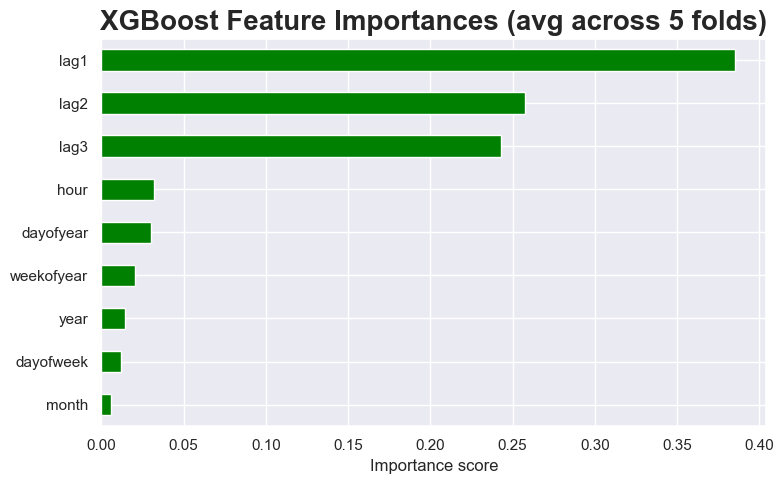

In [70]:
# avg across folds and sort
feature_importances['mean'] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values('mean', ascending=True)

feature_importances['mean'].plot(
  kind='barh',
  figsize=(8, 5),
  title='XGBoost Feature Importances (avg across 5 folds)',
  color="green"
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

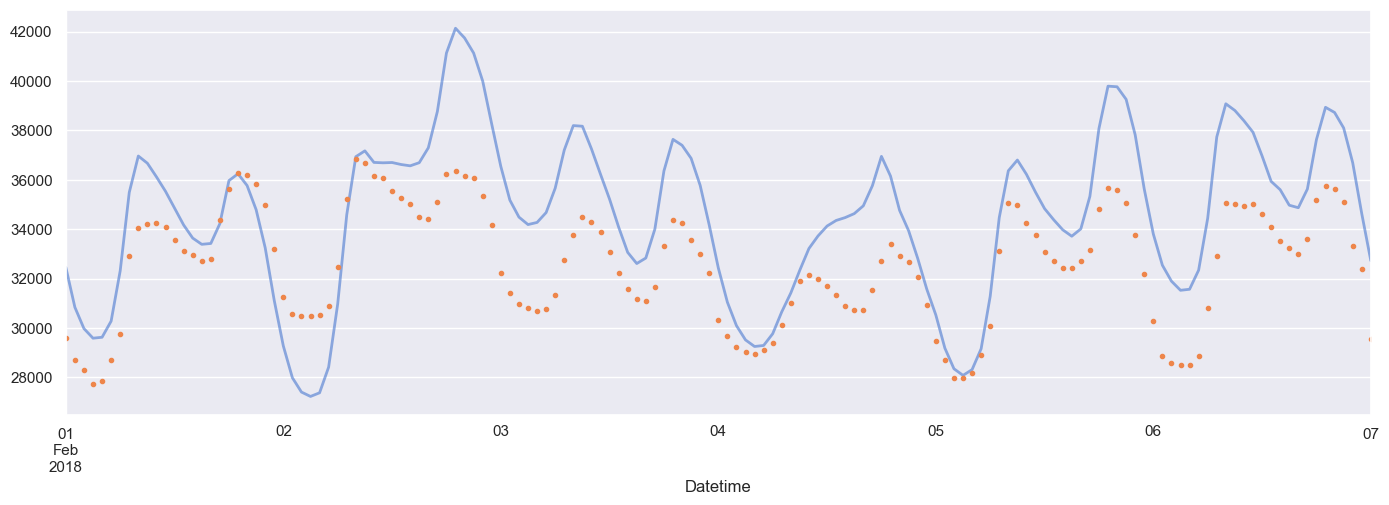

In [82]:
YEAR = 2018
MONTH = 2

mask = (predictions_lag.index >= f'{YEAR}-{MONTH}-01') & (predictions_lag.index <= f'{YEAR}-{MONTH}-07')
predictions_lag.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions_lag.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)
plt.show()

### Add Lag & Rolling Features

In [ ]:
FEATURES = [
  'hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 
  'lag1', 'lag2', 'lag3',
  "rolling_mean_24h",	"rolling_mean_168h"
]

# collect data for the 5 regressors across 5 folds for analysis later
fold_scores = []
predictions_lag_rolling = pd.DataFrame()
feature_importances = pd.DataFrame(index=FEATURES)

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Train XGB
  reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric='rmse'
  )
  reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
  )

  # Predict
  preds = reg.predict(X_test)
  score = np.sqrt(np.mean((preds - y_test)**2)) # RMSE in MW
  fold_scores.append(score)
  print(f"Fold {fold} RMSE: {score:.1f}MW")

  # Save data (feat importances, predictions)
  fold_preds = pd.DataFrame({
    'actual':   y_test.values,
    'predicted': preds,
    'fold':      fold
  }, index=y_test.index)
  predictions_lag_rolling = pd.concat([predictions_lag_rolling, fold_preds])
  feature_importances[f'fold_{fold}'] = reg.feature_importances_

print(f"\nMean RMSE: {np.mean(fold_scores):.1f} ± {np.std(fold_scores):.1f} MW")

[0]	validation_0-rmse:6464.81090	validation_1-rmse:7724.96288
[100]	validation_0-rmse:3619.92920	validation_1-rmse:4629.43427
[200]	validation_0-rmse:2618.77700	validation_1-rmse:3385.86899
[300]	validation_0-rmse:2278.36768	validation_1-rmse:2899.91283
[400]	validation_0-rmse:2134.83858	validation_1-rmse:2699.66147
[500]	validation_0-rmse:2058.95544	validation_1-rmse:2603.76930
[600]	validation_0-rmse:2010.22897	validation_1-rmse:2541.50011
[700]	validation_0-rmse:1973.47094	validation_1-rmse:2495.31227
[800]	validation_0-rmse:1942.45685	validation_1-rmse:2457.85078
[900]	validation_0-rmse:1916.13769	validation_1-rmse:2428.74477
[999]	validation_0-rmse:1894.00356	validation_1-rmse:2407.20356
Fold 0 RMSE: 2407.2MW
[0]	validation_0-rmse:6489.82630	validation_1-rmse:6106.03084
[100]	validation_0-rmse:3635.27455	validation_1-rmse:3696.12288
[200]	validation_0-rmse:2631.55979	validation_1-rmse:2834.99745
[300]	validation_0-rmse:2287.59108	validation_1-rmse:2501.91363
[400]	validation_0-rms

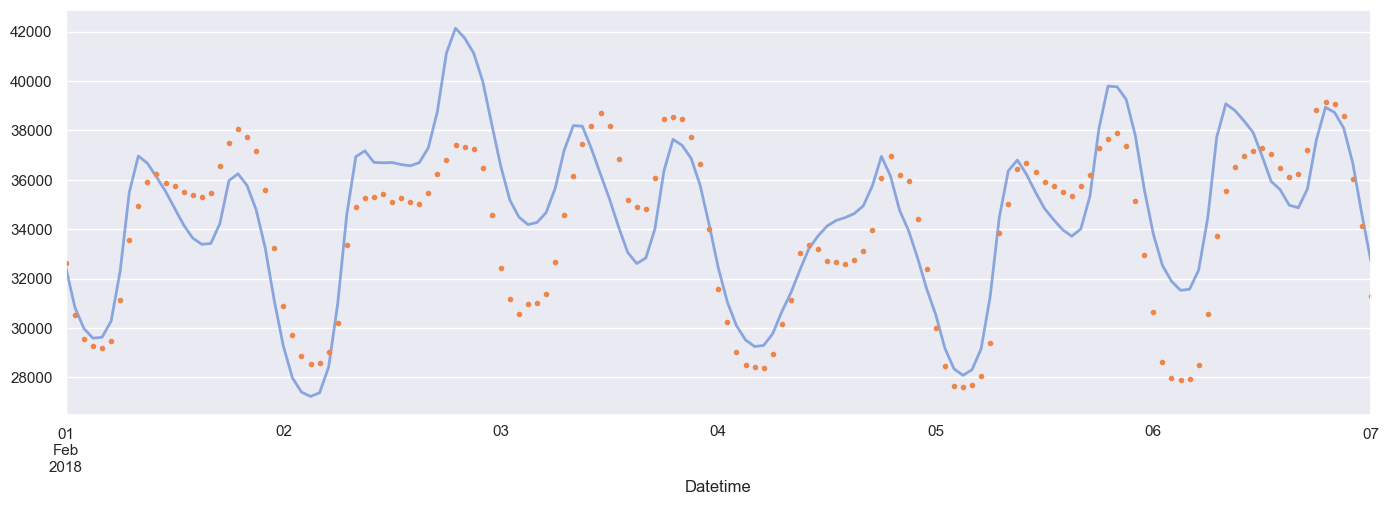

In [73]:
YEAR = 2018
MONTH = 2

mask = (predictions_lag_rolling.index >= f'{YEAR}-{MONTH}-01') & (predictions_lag_rolling.index <= f'{YEAR}-{MONTH}-07')
predictions_lag_rolling.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions_lag_rolling.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)
plt.show()

## Experiment New Techniques & Tune XGBRegressor

### Increase `n_estimators`, `max_depth`, Add `subsample`, `colsample_bytree`

In [ ]:
FEATURES = [
  'hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 
  'lag1', 'lag2', 'lag3',
  "rolling_mean_24h",	"rolling_mean_168h"
]

# collect data for the 5 regressors across 5 folds for analysis later
fold_scores = []
predictions_newxgb = pd.DataFrame()
feature_importances = pd.DataFrame(index=FEATURES)

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Train XGB
  reg = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,            # train each tree on 80% of rows — reduces overfitting
    colsample_bytree=0.8,     # train each tree on 80% of features
    seed=42,                   # prevent randomness for subsample and colsample_bytree params
    early_stopping_rounds=50,
    eval_metric='rmse'
  )
  reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
  )

  # Predict
  preds = reg.predict(X_test)
  score = np.sqrt(np.mean((preds - y_test)**2)) # RMSE in MW
  fold_scores.append(score)
  print(f"Fold {fold} RMSE: {score:.1f}MW")

  # Save data (feat importances, predictions)
  fold_preds = pd.DataFrame({
    'actual':   y_test.values,
    'predicted': preds,
    'fold':      fold
  }, index=y_test.index)
  predictions_newxgb = pd.concat([predictions_newxgb, fold_preds])
  feature_importances[f'fold_{fold}'] = reg.feature_importances_

print(f"\nMean RMSE: {np.mean(fold_scores):.1f} ± {np.std(fold_scores):.1f} MW")

[0]	validation_0-rmse:6459.78008	validation_1-rmse:7719.00821
[100]	validation_0-rmse:3327.34594	validation_1-rmse:4250.85695
[200]	validation_0-rmse:2264.02226	validation_1-rmse:2987.46760
[300]	validation_0-rmse:1917.92743	validation_1-rmse:2524.40522
[400]	validation_0-rmse:1764.81359	validation_1-rmse:2317.18296
[500]	validation_0-rmse:1681.74846	validation_1-rmse:2214.32577
[600]	validation_0-rmse:1629.26737	validation_1-rmse:2153.33630
[700]	validation_0-rmse:1590.53285	validation_1-rmse:2117.05960
[800]	validation_0-rmse:1560.46964	validation_1-rmse:2099.03203
[900]	validation_0-rmse:1536.42268	validation_1-rmse:2086.71345
[1000]	validation_0-rmse:1515.25091	validation_1-rmse:2068.73163
[1100]	validation_0-rmse:1496.41283	validation_1-rmse:2058.90643
[1200]	validation_0-rmse:1479.78345	validation_1-rmse:2050.17403
[1300]	validation_0-rmse:1464.13618	validation_1-rmse:2040.55218
[1400]	validation_0-rmse:1449.97974	validation_1-rmse:2034.64310
[1500]	validation_0-rmse:1436.72706	v

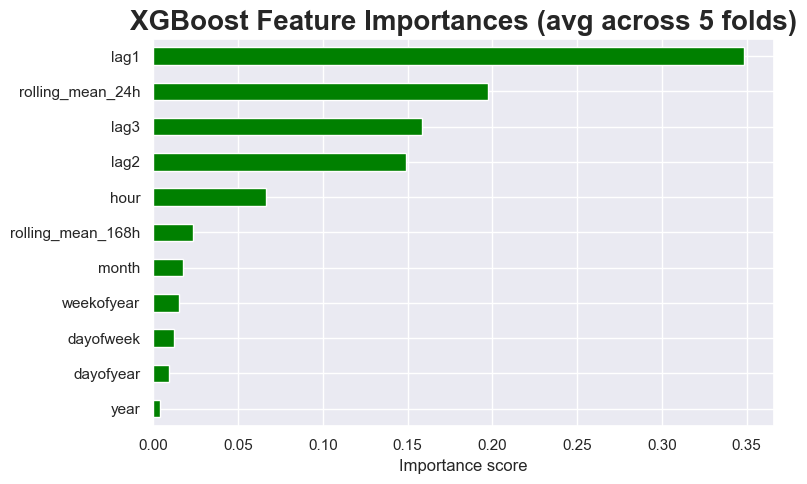

In [76]:
# avg across folds and sort
feature_importances['mean'] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values('mean', ascending=True)

feature_importances['mean'].plot(
  kind='barh',
  figsize=(8, 5),
  title='XGBoost Feature Importances (avg across 5 folds)',
  color="green"
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

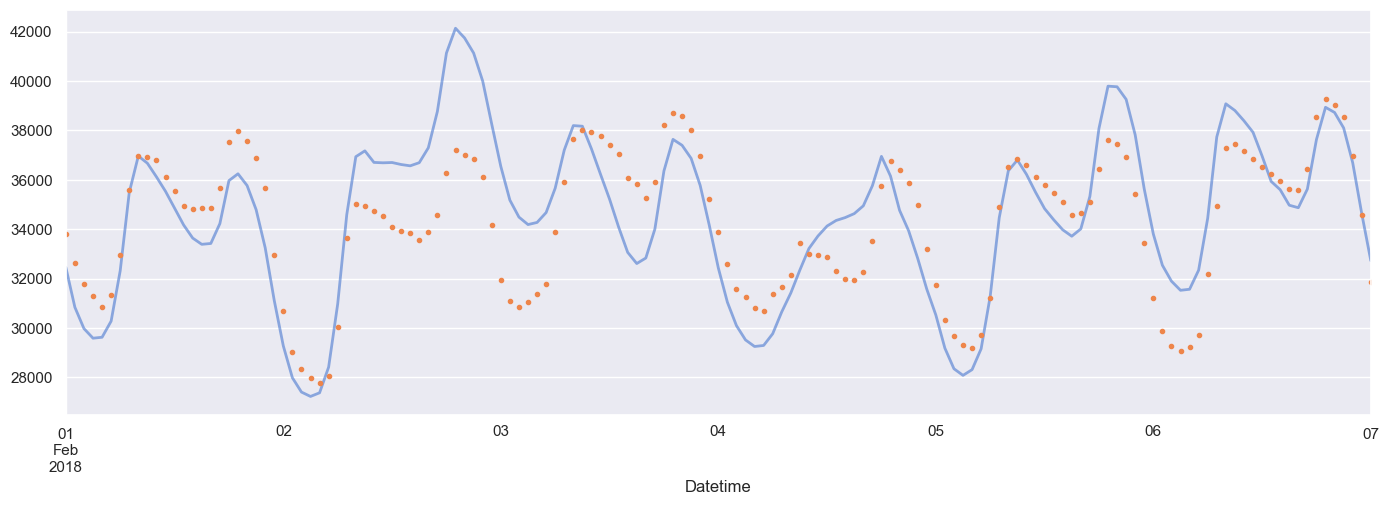

In [77]:
YEAR = 2018
MONTH = 2

mask = (predictions_newxgb.index >= f'{YEAR}-{MONTH}-01') & (predictions_newxgb.index <= f'{YEAR}-{MONTH}-07')
predictions_newxgb.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions_newxgb.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)
plt.show()